In [ ]:
!pip install chart_studio
!pip install plotly
!pip install opensearch-py-ml
!pip install pandas==2.0.3

In [1]:
ABUNDANCE_FILENAME = 'TMT_4plex/abundance_gene_MD.tsv'
ANNOTATION_FILENAME = 'TMT_4plex/experiment_annotation.tsv'
INDEX_NAME = '656a505afdd014a1f3e3fddd_63ddc9ce1e740e0020c39928'
USER_QUERY = "nonSynonymous | (nearest.refSeq.dist > -100 && nearest.refSeq.dist <= 0)"

from bystro.proteomics.annotation_interface import OPENSEARCH_CONFIG, get_annotation_result_from_query, join_annotation_result_to_proteomics_dataset

from bystro.proteomics.fragpipe_tandem_mass_tag import TandemMassTagDataset, load_tandem_mass_tag_dataset
from opensearchpy import OpenSearch
import opensearch_py_ml as oml

client = OpenSearch(**OPENSEARCH_CONFIG)

In [2]:
tmt_dataset = load_tandem_mass_tag_dataset(abundance_filename=ABUNDANCE_FILENAME,
                                           annotation_filename=ANNOTATION_FILENAME)

In [3]:
tmt_dataset.annotation_df

,plex,channel,sample_name,condition,replicate
sample,,,,,
CPT0088900003,16,126,C3N-01179-T,Tumor,1
CPT0079270003,16,127N,C3L-00606-T,Tumor,1
CPT0088920001,16,127C,C3N-01179-N,NAT,1
CPT0079300001,16,128N,C3L-00606-N,NAT,1
CPT0088550004,16,128C,C3N-01648-T,Tumor,1
QC6,16,129N,QC6,QC,1
CPT0014450004,16,129C,C3N-00242-T,Tumor,1
CPT0088570001,16,130N,C3N-01648-N,NAT,1
CPT0014470001,16,130C,C3N-00242-N,NAT,1


In [4]:
tmt_dataset.abundance_df

,NumberPSM,ProteinID,MaxPepProb,ReferenceIntensity,CPT0088900003,CPT0079270003,CPT0088920001,CPT0079300001,CPT0088550004,QC6,...,CPT0007860003,CPT0079380003,CPT0015810003,CPT0086030003,CPT0085670003,CPT0025230003,CPT0065750003,CPT0015730003,CPT0078800003,CPT0079230003
Index,,,,,,,,,,,,,,,,,,,,,
A1BG,324,P04217,1.0,30.044336,0.665648,0.156983,-0.040208,0.647754,-0.948779,-1.029197,...,0.800228,-0.034147,-0.056787,0.721216,0.282223,0.107007,0.947105,-0.203403,-0.612417,0.528959
A1CF,94,Q9NQ94,1.0,26.115335,0.091328,0.228538,0.641523,-0.936936,-1.625079,-1.809748,...,0.443220,-0.679189,-0.447859,-0.529476,0.173284,-1.745636,-0.209171,-0.472092,-0.114567,0.435046
A2M,1418,P01023,1.0,30.802090,0.956687,-0.231766,0.095571,0.859875,-0.668738,-0.657280,...,0.559026,-0.546317,0.272841,0.459240,0.148868,0.224759,0.530004,0.657324,-1.356194,1.095773
AAAS,50,Q9NRG9,1.0,24.422673,-0.005041,0.081379,-0.132121,0.102784,-0.097407,-0.096363,...,0.528265,-0.056627,-0.020744,-0.148636,0.241928,0.105649,-0.047757,-0.022935,0.072918,-0.017612
AACS,65,Q86V21,1.0,27.520496,-0.885569,-0.604937,0.115300,0.116263,-0.682289,0.282590,...,-0.414655,0.244193,0.196228,-0.017570,-1.114966,-0.112935,0.371002,0.215173,0.740686,-0.320558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,3,Q2QGD7,1.0,18.376887,-0.654188,-1.424725,0.296665,1.030376,-1.178351,2.556440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZYG11B,37,Q9C0D3,1.0,23.758588,0.026481,0.128192,0.121819,-0.063792,-0.385797,0.813266,...,0.208455,-0.231912,-0.054855,0.166195,-0.252650,0.315162,0.163858,-0.032966,0.091383,0.206972
ZYX,293,Q15942,1.0,29.773687,0.267343,0.039754,-0.215753,0.027095,0.760614,-0.924936,...,-0.076070,0.416068,0.058444,0.080343,0.349072,0.084721,0.112083,-0.211234,-0.118319,0.239550


In [38]:
from bystro.proteomics.annotation_interface import OPENSEARCH_CONFIG, get_annotation_result_from_query, join_annotation_result_to_proteomics_dataset
from opensearchpy import OpenSearch
from bystro.search.utils.opensearch import gather_opensearch_args

query_result_df = get_annotation_result_from_query(
    USER_QUERY, INDEX_NAME, client  # type: ignore
)

def fake_samples(x):
    print(x)
    if x == '1805':
        return 'CPT0079380003'
    if x == '1847':
        return 'CPT0079230003'
    if x == '4805':
        return 'CPT0065750003'
        

query_result_df['sample_id'] = query_result_df['sample_id'].apply(fake_samples)


source {'alt': [[['T']]], 'heterozygotes': [[[1805]]], 'homozygotes': [[[None]]], 'refSeq': {'codonNumber': [[[None]]], 'codonPosition': [[[None]]], 'name': [[['NR_110260'], ['NM_002977'], ['NM_001365536']]], 'name2': [[['SCN1A-AS1'], ['SCN9A'], ['SCN9A']]]}, 'gnomad': {'genomes': {'AF': [[[0.137850999832153]]]}, 'exomes': {'AF': [[[0.15565200150013]]]}}, 'chrom': [[['chr2']]], 'cadd': [[[3.5]]], 'ref': [[['C']]], 'pos': [[[167137120]]], 'clinvarVcf': {'CLNSIG': [[['Benign']]]}, 'nearestTss': {'refSeq': {'dist': [[[-85423]]], 'name2': [[['SCN9A']]]}}, 'caddIndel': {'PHRED': [[[None]]], 'alt': [[[None]]]}, 'missingGenos': [[[None]]]}
source {'alt': [[['T']]], 'heterozygotes': [[[1805], [1847]]], 'homozygotes': [[[4805]]], 'refSeq': {'codonNumber': [[[None], [429], [429]]], 'codonPosition': [[[None], [3], [3]]], 'name': [[['NR_110260'], ['NM_002977'], ['NM_001365536']]], 'name2': [[['SCN1A-AS1'], ['SCN9A'], ['SCN9A']]]}, 'gnomad': {'genomes': {'AF': [[[0.565405011177063]]]}, 'exomes': {'

In [39]:
query_result_df

,sample_id,chrom,pos,ref,alt,gene_name,dosage,cadd,caddIndel,gnomad_genomes_af,gnomad_exomes_af
0,CPT0079380003,chr2,167137120,C,T,SCN1A-AS1,1,3.5,None,0.137851,0.155652
1,CPT0079380003,chr2,167137120,C,T,SCN9A,1,3.5,None,0.137851,0.155652
0,CPT0079380003,chr2,167144974,A,T,SCN1A-AS1,1,9.0,11.38,0.565405,0.493275
1,CPT0079230003,chr2,167144974,A,T,SCN1A-AS1,1,9.0,11.38,0.565405,0.493275
2,CPT0065750003,chr2,167144974,A,T,SCN1A-AS1,2,9.0,11.38,0.565405,0.493275
3,CPT0079380003,chr2,167144974,A,T,SCN9A,1,9.0,11.38,0.565405,0.493275
4,CPT0079230003,chr2,167144974,A,T,SCN9A,1,9.0,11.38,0.565405,0.493275
5,CPT0065750003,chr2,167144974,A,T,SCN9A,2,9.0,11.38,0.565405,0.493275
0,CPT0079380003,chr2,167144995,T,C,SCN1A-AS1,1,11.6,None,0.399744,0.367272
1,CPT0079230003,chr2,167144995,T,C,SCN1A-AS1,1,11.6,None,0.399744,0.367272


In [40]:
query_result_df

,sample_id,chrom,pos,ref,alt,gene_name,dosage,cadd,caddIndel,gnomad_genomes_af,gnomad_exomes_af
0,CPT0079380003,chr2,167137120,C,T,SCN1A-AS1,1,3.5,None,0.137851,0.155652
1,CPT0079380003,chr2,167137120,C,T,SCN9A,1,3.5,None,0.137851,0.155652
0,CPT0079380003,chr2,167144974,A,T,SCN1A-AS1,1,9.0,11.38,0.565405,0.493275
1,CPT0079230003,chr2,167144974,A,T,SCN1A-AS1,1,9.0,11.38,0.565405,0.493275
2,CPT0065750003,chr2,167144974,A,T,SCN1A-AS1,2,9.0,11.38,0.565405,0.493275
3,CPT0079380003,chr2,167144974,A,T,SCN9A,1,9.0,11.38,0.565405,0.493275
4,CPT0079230003,chr2,167144974,A,T,SCN9A,1,9.0,11.38,0.565405,0.493275
5,CPT0065750003,chr2,167144974,A,T,SCN9A,2,9.0,11.38,0.565405,0.493275
0,CPT0079380003,chr2,167144995,T,C,SCN1A-AS1,1,11.6,None,0.399744,0.367272
1,CPT0079230003,chr2,167144995,T,C,SCN1A-AS1,1,11.6,None,0.399744,0.367272


In [42]:
df = join_annotation_result_to_proteomics_dataset(
    query_result_df=query_result_df,
    tmt_dataset=tmt_dataset)

In [33]:
"SFTPB" in set(tmt_dataset.abundance_df.index)

True

In [37]:
tmt_dataset.abundance_df[tmt_dataset.abundance_df.index == 'SFTPB']

,NumberPSM,ProteinID,MaxPepProb,ReferenceIntensity,CPT0088900003,CPT0079270003,CPT0088920001,CPT0079300001,CPT0088550004,QC6,...,CPT0007860003,CPT0079380003,CPT0015810003,CPT0086030003,CPT0085670003,CPT0025230003,CPT0065750003,CPT0015730003,CPT0078800003,CPT0079230003
Index,,,,,,,,,,,,,,,,,,,,,
SFTPB,1,P07988,1.0,21.659044,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.770419,-0.17175,0.84026,0.225783,-0.219452,0.949165,-0.29028,-1.361787,0.445432


In [43]:
df

,sample_id,chrom,pos,ref,alt,gene_name,dosage,cadd,caddIndel,gnomad_genomes_af,gnomad_exomes_af,value
0,CPT0079380003,chr2,85893741,G,A,SFTPB,1,10.5,None,0.575432,0.495119,0.770419
1,CPT0079380003,chr2,85890771,T,G,SFTPB,2,5.3,3.442,0.934385,0.937018,0.770419
2,CPT0079230003,chr2,85893741,G,A,SFTPB,1,10.5,None,0.575432,0.495119,0.445432
3,CPT0079230003,chr2,85895338,T,G,SFTPB,1,5.0,None,0.382086,0.410786,0.445432
4,CPT0079230003,chr2,85890758,T,C,SFTPB,1,4.5,None,0.195262,0.212093,0.445432
5,CPT0079230003,chr2,85890771,T,G,SFTPB,2,5.3,3.442,0.934385,0.937018,0.445432
6,CPT0065750003,chr2,85893741,G,A,SFTPB,1,10.5,None,0.575432,0.495119,0.949165
7,CPT0065750003,chr2,85895338,T,G,SFTPB,1,5.0,None,0.382086,0.410786,0.949165
8,CPT0065750003,chr2,85890758,T,C,SFTPB,1,4.5,None,0.195262,0.212093,0.949165
9,CPT0065750003,chr2,85890771,T,G,SFTPB,2,5.3,3.442,0.934385,0.937018,0.949165


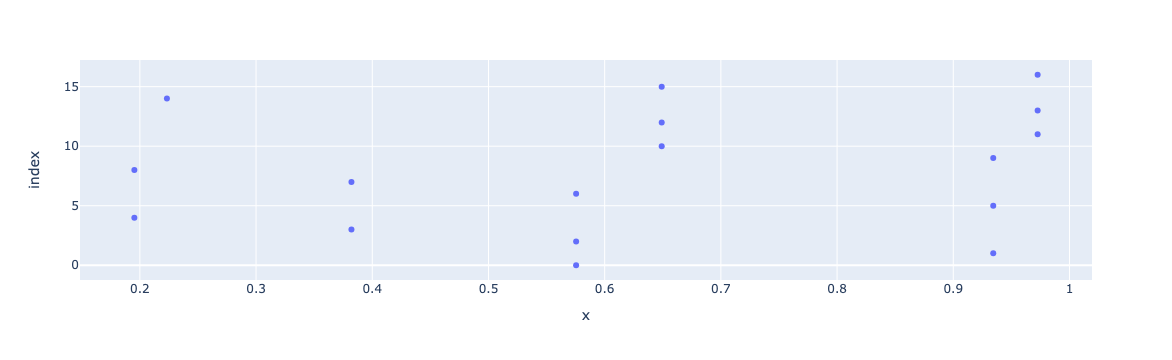

In [36]:
## Plot Stuff
# 1) Mom, dad, child for a given gene, a dot plot
# 2) Make a bar plot, of mom dad child of all genes
# 3) Condition on your favorite variant, and show the dosages
# 4) Average abundance of the protein, and a different abundance 
# 5) Average abundance by allele type

import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff

px.scatter(df['dosage'], df['gnomad_genomes_af'])

In [16]:
py.iplot(px.scatter(df['gnomad_exomes_af'], df['value']), filename='jupyter-table1')

PlotlyRequestError: Authentication credentials were not provided.

In [14]:
df['gnomad_exomes_af'].mean()

0.45554560916894377

In [10]:
df['gnomad_exomes_af'].std()

0.3014046165225443

In [52]:
# Python code to illustrate 
# working of try()  
def divide(x, y): 
    try: 
        # Floor Division : Gives only Fractional 
        # Part as Answer 
        result = x // y 
    except ZeroDivisionError: 
        print("Sorry ! You are dividing by zero ") 
        raise Exception("FUCK YOU")
    else: 
        print("Yeah ! Your answer is :", result) 
    finally:  
        # this block is always executed   
        # regardless of exception generation.  
        print('This is always executed')   
 
# Look at parameters and note the working of Program 
divide(3, 2) 
divide(3, 0)

Yeah ! Your answer is : 1
This is always executed
Sorry ! You are dividing by zero 
This is always executed


Exception: FUCK YOU